## HuggingFace Transformers: API, Models and Fine-Tuning Techniques
### Day 2: Exploring transformers for inferencing using Task-specific models

---

### Planned agenda for today

#### Module 2: The Transformers API Foundation
- **The Pipeline API: Zero-Shot Inference**
  - Understanding the high-level pipeline abstraction
  - Default models and task-specific pipelines
  - Batch processing with pipelines

- **Tokenizer Fundamentals**
  - Tokenization strategies: BPE, WordPiece, SentencePiece
  - The tokenizer-model relationship
  - Padding, truncation, and attention masks
  - Special tokens and their significance

- **Hands-on Lab**
  - Running inference with pipelines (sentiment analysis, NER, summarization)
  - Tokenization deep dive: encoding/decoding text
  - Comparing tokenizers across model architectures
  - Handling variable-length sequences and batching

#### Module 3: Model Architectures and Task-Specific Models
- **Encoder-Only Models (BERT Family)**
  - Architecture: Bidirectional attention, MLM pre-training
  - Use cases: Classification, NER, Question Answering
  - Understanding hidden states and contextual embeddings
  - Model variants: RoBERTa, DeBERTa, ALBERT, ModernBERT

- **Decoder-Only Models (GPT Family)**
  - Architecture: Causal attention, autoregressive generation
  - Use cases: Text generation, chat, code generation
  - Generation strategies: greedy, beam search, sampling, temperature
  - Model variants: GPT-2, GPT-Neo, Phi, Gemma, SmolLM2

- **Hands-on Lab**
  - Feature extraction with BERT: obtaining embeddings
  - Text generation with GPT models and parameter tuning
  - Comparing generation strategies visually
  - Experimenting with small models suitable for local execution

#### Module 4: Encoder-Decoder and Multimodal Models
- **Encoder-Decoder Models (T5, BART)**
  - Architecture and seq2seq paradigm
  - Use cases: Translation, summarization, text-to-text tasks
  - Task-specific prompting with T5

- **Multimodal Transformers**
  - Vision Transformers (ViT) for image classification
  - CLIP and vision-language models
  - Speech and audio models overview (Whisper)

- **Hands-on Lab**
  - Translation and summarization with T5/BART
  - Image classification with ViT
  - Zero-shot image classification with CLIP
  - Basic speech recognition with Whisper-tiny


---

### Sign in to HuggingFace

In [ ]:
# Load the Hugging Face token from the .env file

from dotenv import load_dotenv
import os
load_dotenv("../../myenv.sh")
HF_TOKEN = os.getenv("HF_TOKEN")

In [ ]:
# Sign in to Hugging Face Hub using the token
from huggingface_hub import login
login(token=HF_TOKEN) 
# NOTE: If the environment variable by name HF_TOKEN is set,
# the login() function will automatically use it, 
# so you can also just call login() without any arguments.

---

### Explore HuggingFace Hub Programmatically


In [3]:
import huggingface_hub as hf

# List top 10 models sorted by most downloads
for model in hf.list_models(sort="downloads", limit=10):
    print(f"Model: {model.modelId}, Downloads: {model.downloads:,}")

Model: sentence-transformers/all-MiniLM-L6-v2, Downloads: 258,193,926
Model: google-bert/bert-base-uncased, Downloads: 111,424,688
Model: cross-encoder/ms-marco-MiniLM-L6-v2, Downloads: 89,247,481
Model: BAAI/bge-small-en-v1.5, Downloads: 73,518,672
Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2, Downloads: 56,248,525
Model: google/electra-base-discriminator, Downloads: 56,124,815
Model: amazon/chronos-2, Downloads: 38,402,399
Model: BAAI/bge-m3, Downloads: 35,595,931
Model: lpiccinelli/unidepth-v2-vitl14, Downloads: 34,869,865
Model: Qwen/Qwen3-0.6B, Downloads: 28,826,416


In [ ]:
list_models?

In [4]:
model

ModelInfo(id='Qwen/Qwen3-0.6B', author=None, base_models=None, card_data=None, children_model_count=None, config=None, created_at=datetime.datetime(2025, 4, 27, 3, 40, 8, tzinfo=datetime.timezone.utc), disabled=None, downloads=28826416, downloads_all_time=None, eval_results=None, gated=None, gguf=None, inference=None, inference_provider_mapping=None, last_modified=None, library_name='transformers', likes=1516, mask_token=None, model_index=None, pipeline_tag='text-generation', private=False, resource_group=None, safetensors=None, security_repo_status=None, sha=None, siblings=None, spaces=None, tags=['transformers', 'safetensors', 'qwen3', 'text-generation', 'conversational', 'arxiv:2505.09388', 'base_model:Qwen/Qwen3-0.6B-Base', 'base_model:finetune:Qwen/Qwen3-0.6B-Base', 'license:apache-2.0', 'text-generation-inference', 'endpoints_compatible', 'region:us', 'deploy:sagemaker', 'deploy:azure'], transformers_info=None, trending_score=None, used_storage=None, widget_data=None)

In [5]:
print(f"{model.id=}")
print(f"{model.modelId=}")
print(f"{model.pipeline_tag=}")
print(f"{model.library_name=}")
print(f"{model.downloads=}")
print(f"{model.likes=}")
print(f"{model.created_at=}")
print(f"{model.tags=}")
print(f"{model.gated=}")
print(f"{model.author=}")
print(f"{model.base_models=}")
print(f"{model.card_data=}")
print(f"{model.config=}")
print(f"{model.children_model_count=}")


model.id='Qwen/Qwen3-0.6B'
model.modelId='Qwen/Qwen3-0.6B'
model.pipeline_tag='text-generation'
model.library_name='transformers'
model.downloads=28826416
model.likes=1516
model.created_at=datetime.datetime(2025, 4, 27, 3, 40, 8, tzinfo=datetime.timezone.utc)
model.tags=['transformers', 'safetensors', 'qwen3', 'text-generation', 'conversational', 'arxiv:2505.09388', 'base_model:Qwen/Qwen3-0.6B-Base', 'base_model:finetune:Qwen/Qwen3-0.6B-Base', 'license:apache-2.0', 'text-generation-inference', 'endpoints_compatible', 'region:us', 'deploy:sagemaker', 'deploy:azure']
model.gated=None
model.author=None
model.base_models=None
model.card_data=None
model.config=None
model.children_model_count=None


In [7]:
# Find models for a specific task

import huggingface_hub as hf

api = hf.HfApi()

sentiment_models = list(api.list_models(
   filter="text-classification", 
   sort="likes", 
   limit=5
))

for model in sentiment_models:
    print(f"Model: {model.modelId}, Likes: {model.likes:,}, Downloads: {model.downloads:,}")

Model: facebook/bart-large-mnli, Likes: 1,595, Downloads: 3,206,803
Model: ProsusAI/finbert, Likes: 1,220, Downloads: 4,703,323
Model: BAAI/bge-reranker-v2-m3, Likes: 1,138, Downloads: 18,760,554
Model: distilbert/distilbert-base-uncased-finetuned-sst-2-english, Likes: 940, Downloads: 3,623,613
Model: cardiffnlp/twitter-roberta-base-sentiment-latest, Likes: 825, Downloads: 2,893,181


In [ ]:
for model in hf.list_models(
    filter="llama", 
    sort="downloads", 
    limit=5, 
    gated=False):

    print(f"Model: {model.modelId}, Tags: {model.tags}")

---

### Load and inspect a model


In [10]:
from transformers import AutoConfig

model_name = "bert-base-uncased"
#model_name = "distilbert-base-uncased-distilled-squad"
config = AutoConfig.from_pretrained(model_name)
print(f"Model type: {config.model_type}")
print(f"Number of hidden layers: {config.num_hidden_layers}")
print(f"Hidden size: {config.hidden_size}")
print(f"Number of attention heads: {config.num_attention_heads}")
print(f"Vocabulary size: {config.vocab_size}")

Model type: bert
Number of hidden layers: 12
Hidden size: 768
Number of attention heads: 12
Vocabulary size: 30522


In [11]:
config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.15.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

#### Factory methods in ```transformers```

The ```transformers``` module implements the factory-method design pattern to return a corresponding model, model-config and model-specific tokenizers for most models.

- The ```AutoConfig.from_pretrained(model_name: str)``` returns model config object corresponding to the passed pretrained model name as a string

- The ```AutoModel.from_pretrained(model_name: str)``` returns the corresponding model object with model weights from a pretrained model_name passed as a string

- The ```AutoTokenizer.from_pretrained(model_name: str)``` returns the corresponding tokenizer object suitable to the model passed as model_name (as a string).

NOTE: In most cases, to load model with pretrained model weights, you might want to select a task-specific factory method. For example:
  - ```AutoModelForSequenceClassification``` for classification tasks.
  - ```AutoModelForCausalLM``` for text generation (Generative Autoregressive tasks).
  - ```AutoModelForQuestionAnswering``` for QA related tasks.
  - ```AutoModelForSeq2SeqLM``` for translation, summarization.

The list of task-specific Auto classes are documented at https://huggingface.co/docs/transformers/main/en/model_doc/auto#natural-language-processing

For official tutorial, lookup https://huggingface.co/docs/transformers/models

In [ ]:
config

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(f"Tokenizer: {tokenizer}")

In [12]:
from transformers import AutoModel

MODEL_NAME = "ProsusAI/finbert"
model = AutoModel.from_pretrained(MODEL_NAME)
model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [13]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [14]:
from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-uncased")
print(f"Model: {model}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dro

In [15]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
print(f"Model: {model}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm(

In [17]:
from transformers import AutoModel

MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(MODEL_NAME)

model

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.bias   | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [ ]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, 
                                                           num_labels=2)

model

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [ ]:
# Silence warning about UNEXPECTED keys
import logging

logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
print(f"Tokenizer: {tokenizer}")
print(f"Model: {model}")

In [ ]:

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters in the model: {total_params:,}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters in the model: {trainable_params:,}")


---

### Tokenizer Deep Dive


In [ ]:
from transformers import AutoTokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer

In [ ]:
#text = "The transformer model is revolutionizing NLP!"

text = "Hi, How are you doing today? I hope you're having a great day!"

# Tokenize -> Encode -> Decode
tokens = tokenizer.tokenize(text)
print(f"Tokens: {tokens}")


In [ ]:
text = "Python is an easy language for ML workflow. Python is freely downloadable."
print(tokenizer(text))
print(tokenizer.tokenize(text))


In [ ]:

encoded = tokenizer(text)
print(f"Encoded input IDs: {encoded['input_ids']}")
print(f"Attn Mask: {encoded['attention_mask']}")

decoded = tokenizer.decode(encoded['input_ids'])
print(f"Decoded text: {decoded}")

In [ ]:
# Batch encoding with padding
texts = [
    "Transformers are amazing but complex. Python makes it easy.",
    "Python is cool."
] 

batch_encoded = tokenizer(texts, padding='max_length', max_length=25)
print(batch_encoded)
#print(f"\nBatch shape: {batch_encoded['input_ids'].shape}")
#print(f"Padded IDs:\n{batch_encoded['input_ids']}")

In [ ]:
tokenizer?

---

### Download and Explore a Dataset

In [ ]:
from datasets import load_dataset

# Load IMDB dataset for sentiment analysis
dataset = load_dataset("stanfordnlp/imdb")
dataset

In [ ]:
for d in dataset["train"]:
    if d["label"] == 1:
        print(f"Positive review: {d['text']}")
        break

In [ ]:

print(f"Dataset splits: {dataset.keys()}")
print(f"Train size: {len(dataset['train'])}")
print(f"Test size: {len(dataset['test'])}")

# Explore a sample
sample = dataset['train'][0]
print(f"\nSample text: {sample['text'][:200]}...")
print(f"Label: {sample['label']} ({'Positive' if sample['label'] == 1 else 'Negative'})")

# Check label distribution
from collections import Counter
labels = dataset['train']['label']
print(f"\nLabel distribution: {Counter(labels)}")

# Load a specific subset (faster for experimentation)
small_train = dataset['train'].select(range(1000))
small_test = dataset['test'].select(range(500))
print(f"\nSmall train size: {len(small_train)}")
print(f"Small test size: {len(small_test)}")

---

### Using the ```pipeline()``` from the ```transformers``` library

In [ ]:
from transformers import pipeline

MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

classifier = pipeline("sentiment-analysis", model=MODEL_NAME)
print(classifier)
print("-" * 40)

result = classifier("I love machine learning!")
print(result)

result = classifier("Transformers are amazing but complex.")
print(result)

result = classifier("I hate bugs in my code.")
print(result)

---

### Pipeline Examples: NLP Tasks


In [ ]:
# 1. Sentiment Analysis
from transformers import pipeline
#classifier = pipeline("sentiment-analysis", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
classifier = pipeline("sentiment_analysis")
results = classifier(["Great product!", "Terrible experience..."])
# [{'label': 'POSITIVE', 'score': 0.99}, {'label': 'NEGATIVE', 'score': 0.98}]
print(results)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998729228973389}, {'label': 'NEGATIVE', 'score': 0.9996969699859619}]


In [3]:
# 2. Named Entity Recognition

from transformers import pipeline

MODEL_NAME = "dbmdz/bert-large-cased-finetuned-conll03-english"

#MODEL_NAME = "dslim/bert-base-NER"

ner = pipeline("ner", aggregation_strategy="simple", model=MODEL_NAME)



#text = "Elon Musk founded SpaceX in Hawthorne, California."
text = "Chandrashekar is a corporate trainer and technologist in FOSS who lives in Chennai, India and currently trains for Qualcomm"
entities = ner(text)

print(entities)
for entity in entities:
    print(f"Entity: {entity['word']}, Type: {entity['entity_group']}, Score: {entity['score']:.4f}") 

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity_group': 'PER', 'score': np.float32(0.99404097), 'word': 'Chandrashekar', 'start': 0, 'end': 13}, {'entity_group': 'ORG', 'score': np.float32(0.99515414), 'word': 'FOSS', 'start': 57, 'end': 61}, {'entity_group': 'LOC', 'score': np.float32(0.9991007), 'word': 'Chennai', 'start': 75, 'end': 82}, {'entity_group': 'LOC', 'score': np.float32(0.9994973), 'word': 'India', 'start': 84, 'end': 89}, {'entity_group': 'ORG', 'score': np.float32(0.96090555), 'word': 'Qualcomm', 'start': 115, 'end': 123}]
Entity: Chandrashekar, Type: PER, Score: 0.9940
Entity: FOSS, Type: ORG, Score: 0.9952
Entity: Chennai, Type: LOC, Score: 0.9991
Entity: India, Type: LOC, Score: 0.9995
Entity: Qualcomm, Type: ORG, Score: 0.9609


In [6]:
# 2. Named Entity Recognition

from transformers import pipeline

#MODEL_NAME = "dbmdz/bert-large-cased-finetuned-conll03-english"

MODEL_NAME = "dslim/bert-base-NER"

ner = pipeline("ner", aggregation_strategy="simple", model=MODEL_NAME)



#text = "Elon Musk founded SpaceX in Hawthorne, California."
text = "Chandrashekar is a corporate trainer and technologist in FOSS who lives in Chennai, India and currently trains for Qualcomm"
entities = ner(text)

print(entities)
for entity in entities:
    print(f"Entity: {entity['word']}, Type: {entity['entity_group']}, Score: {entity['score']:.4f}") 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity_group': 'PER', 'score': np.float32(0.99186116), 'word': 'Chandrashekar', 'start': 0, 'end': 13}, {'entity_group': 'ORG', 'score': np.float32(0.99775463), 'word': 'F', 'start': 57, 'end': 58}, {'entity_group': 'ORG', 'score': np.float32(0.9850377), 'word': '##OSS', 'start': 58, 'end': 61}, {'entity_group': 'LOC', 'score': np.float32(0.9992567), 'word': 'Chennai', 'start': 75, 'end': 82}, {'entity_group': 'LOC', 'score': np.float32(0.99953854), 'word': 'India', 'start': 84, 'end': 89}, {'entity_group': 'ORG', 'score': np.float32(0.97598845), 'word': 'Qualcomm', 'start': 115, 'end': 123}]
Entity: Chandrashekar, Type: PER, Score: 0.9919
Entity: F, Type: ORG, Score: 0.9978
Entity: ##OSS, Type: ORG, Score: 0.9850
Entity: Chennai, Type: LOC, Score: 0.9993
Entity: India, Type: LOC, Score: 0.9995
Entity: Qualcomm, Type: ORG, Score: 0.9760


In [4]:
import transformers
print(f"Transformers version: {transformers.__version__}")

Transformers version: 5.15.0


In [8]:
# 3. Question-Answering

# WARNING: "question-answering" pipeline is not implemented as yet
# in HuggingFace transformers 5.x. 
# This code will work on transformers 4.x, but may not work on 5.x.

from transformers import pipeline

#MODEL_NAME = "distilbert/distilbert-base-cased-distilled-squad"
MODEL_NAME = "deepset/roberta-base-squad2"
qa = pipeline("question-answering", model=MODEL_NAME)

result = qa(
    #question="What is the capital of France?",
    question="Where is France located?",
    context="France is a country in Western Europe. Its capital is Paris."
)
print(result)

print(result["answer"])

Device set to use mps:0


{'score': 0.7406781315803528, 'start': 23, 'end': 37, 'answer': 'Western Europe'}
Western Europe


In [13]:
# 4. Summarization

from transformers import pipeline

MODEL_NAME = "Falconsai/text_summarization"
#MODEL_NAME = "facebook/bart-large-cnn"
#MODEL_NAME = "t5-small"  # Using T5 model for summarization
# MODEL_NAME = "sshleifer/distilbart-cnn-12-6"

# device = torch.accelerator.current_accelerator().name
# summarizer = pipeline("summarization", model=MODEL_NAME, device=device)

summarizer = pipeline("summarization", model=MODEL_NAME)
print(summarizer)

text = """
America has changed dramatically during recent years. Not only has the number of
graduates in traditional engineering disciplines such as mechanical, civil,
electrical, chemical, and aeronautical engineering declined, but in most of
the premier American universities engineering curricula now concentrate on
and encourage largely the study of engineering science. As a result, there
are declining offerings in engineering subjects dealing with infrastructure,
the environment, and related issues, and greater concentration on high
technology subjects, largely supporting increasingly complex scientific
developments. While the latter is important, it should not be at the expense
of more traditional engineering.

Rapidly developing economies such as China and India, as well as other
industrial countries in Europe and Asia, continue to encourage and advance
the teaching of engineering. Both China and India, respectively, graduate
six and eight times as many traditional engineers as does the United States.
Other industrial countries at minimum maintain their output, while America
suffers an increasingly serious decline in the number of engineering graduates
and a lack of well-educated engineers.
"""


text2 = """The transformer model, introduced in the paper 'Attention Is All You Need',
has revolutionized the field of natural language processing. Unlike previous 
sequence-to-sequence models that relied on recurrent neural networks, the 
transformer uses self-attention mechanisms to process entire sequences 
simultaneously, enabling better parallelization and capturing long-range 
dependencies more effectively."""

summary = summarizer(text, max_length=42, min_length=25)
print(summary)
print("=" * 40)
print(f"Summary: {summary[0]['summary_text']}")

Device set to use mps:0
Both `max_new_tokens` (=256) and `max_length`(=42) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'summary_text': 'In most of the premier American universities engineering curricula now concentrate on and encourage largely the study of engineering science . As result, there are declining offerings in engineering subjects dealing with infrastructure, the environment, and related issues, and greater concentration on high technology subjects . Rapidly developing economies such as China and India continue to encourage and advance the teaching of engineering . Both China and Indian graduate six and eight times as many traditional engineers as does the United States .'}]
Summary: In most of the premier American universities engineering curricula now concentrate on and encourage largely the study of engineering science . As result, there are declining offerings in engineering subjects dealing with infrastructure, the environment, and related issues, and greater concentration on high technology subjects . Rapidly developing economies such as China and India continue to encourage and adva

In [ ]:
# 4. Summarization

from transformers import pipeline

#MODEL_NAME = "Falconsai/text_summarization"
#MODEL_NAME = "facebook/bart-large-cnn"
#MODEL_NAME = "t5-small"  # Using T5 model for summarization
MODEL_NAME = "sshleifer/distilbart-cnn-12-6"

# device = torch.accelerator.current_accelerator().name
# summarizer = pipeline("summarization", model=MODEL_NAME, device=device)

summarizer = pipeline("summarization")
print(summarizer)
text = """The transformer model, introduced in the paper 'Attention Is All You Need',
has revolutionized the field of natural language processing. Unlike previous 
sequence-to-sequence models that relied on recurrent neural networks, the 
transformer uses self-attention mechanisms to process entire sequences 
simultaneously, enabling better parallelization and capturing long-range 
dependencies more effectively."""

summary = summarizer(text, max_length=50, min_length=25)
print(f"Summary: {summary[0]['summary_text']}")

---

### Using the ```pipeline()``` from the ```transformers``` library

> NOTE: transformers 5.x has introduced breaking changes in their architecture.

> Thus, many tasks like question-answering / summarization are not available via
> the pipeline() API.  

> Also, many models that are not updated recently would fail to work with transformers 5.x. This includes a lot of ASR, Text-To-Speech and Image generation models.

> The fix is currently underway. Until then, it is better to explore transformers 4.x for our examples where transformers 5.x breaks.

To create a seperate environment for experimenting with transformers 4.x:
```bash
   conda create -n hf4_env python=3.11 jupyter -y
   conda activate hf4_env
   conda install -c conda-forge "transformers>=4.40,<5.0" \
                    datasets evaluate accelerate          \
                    pytorch torchvision torchaudio -y
```

In [1]:
import transformers
print(f"Transformers version: {transformers.__version__}")

Transformers version: 4.57.6


In [ ]:
import transformers
print(f"Transformers version: {transformers.__version__}")

> NOTE: If you get SSLVerificationError, try running the following command:
```bash
conda config --set ssl_verify false
```

And then try installing

In [ ]:
import transformers
import torch
import sys
print("Transformers version:", transformers.__version__)
print("Torch version:", torch.__version__)
print("Python version:", sys.version)

print("Accelerator: ", torch.accelerator.current_accelerator())

In [ ]:
from transformers import pipeline

pipeline?

In [2]:
from transformers import pipeline
classifier = pipeline(task="sentiment-analysis", 
                      model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
result = classifier("I love machine learning!")
print(result)

result = classifier("Transformers are amazing but complex.")
print(result)

result = classifier("I hate bugs in my code.")
print(result)
print(result[0]["label"], result[0]["score"])

Device set to use mps:0


[{'label': 'POSITIVE', 'score': 0.9998431205749512}]
[{'label': 'POSITIVE', 'score': 0.9989979863166809}]
[{'label': 'NEGATIVE', 'score': 0.999018669128418}]
NEGATIVE 0.999018669128418


---

### Pipeline Examples: NLP Tasks


In [ ]:
# 1. Sentiment Analysis
classifier = pipeline("sentiment-analysis", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
results = classifier(["Great product!", "Terrible experience..."])
# [{'label': 'POSITIVE', 'score': 0.99}, {'label': 'NEGATIVE', 'score': 0.98}]
print(results)


In [ ]:
# Silencing warnings for cleaner output (needed for transformers 5.x)
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

In [3]:
# 2. Named Entity Recognition (ner)
from transformers import pipeline
ner = pipeline(task="ner", 
               aggregation_strategy="simple", 
               model="dbmdz/bert-large-cased-finetuned-conll03-english")

#text = "Elon Musk founded SpaceX in Hawthorne, California."
text = "Chandrashekar is a managing director of Slashprog Technologies, lives in Chennai, India and trains for Qualcomm."
entities = ner(text)
print("---- Named Entities ---")
print(entities)


Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


---- Named Entities ---
[{'entity_group': 'PER', 'score': np.float32(0.9917142), 'word': 'Chandrashekar', 'start': 0, 'end': 13}, {'entity_group': 'ORG', 'score': np.float32(0.9913398), 'word': 'Slashprog Technologies', 'start': 40, 'end': 62}, {'entity_group': 'LOC', 'score': np.float32(0.9992513), 'word': 'Chennai', 'start': 73, 'end': 80}, {'entity_group': 'LOC', 'score': np.float32(0.99959594), 'word': 'India', 'start': 82, 'end': 87}, {'entity_group': 'ORG', 'score': np.float32(0.974483), 'word': 'Qualcomm', 'start': 103, 'end': 111}]


In [ ]:
for entity in entities:
    print(f"Entity: {entity['word']}, Type: {entity['entity_group']}, Score: {entity['score']:.4f}") 

In [ ]:
p = pipeline("question-answering", model="distilbert/distilbert-base-cased-distilled-squad")
p

In [ ]:
pipeline?

In [21]:
from transformers import pipeline

#MODEL_NAME = "gpt2"
#MODEL_NAME = "Qwen/Qwen3-0.6B"
MODEL_NAME = "google/gemma-3-1b-it"
text_gen = pipeline("text-generation", model=MODEL_NAME)
result = text_gen("The distance between Earth and Moon is", max_new_tokens=32, temperature=0.7)
print(result)
print("-" * 40)
print(result[0]["generated_text"])

Device set to use mps:0


[{'generated_text': "The distance between Earth and Moon is constantly changing. It varies between about 362,000 miles and 384,400 miles.\n\nThe Moon's"}]
----------------------------------------
The distance between Earth and Moon is constantly changing. It varies between about 362,000 miles and 384,400 miles.

The Moon's


In [23]:
from transformers import pipeline

#MODEL_NAME = "gpt2"
#MODEL_NAME = "Qwen/Qwen3-0.6B"
MODEL_NAME = "google/gemma-3-1b-it"
text_gen = pipeline("text-generation", model=MODEL_NAME)
result = text_gen("What is the distance between Earth and Moon?", max_new_tokens=100, temperature=0.7)
print(result)
print("-" * 40)
print(result[0]["generated_text"])

Device set to use mps:0


[{'generated_text': 'What is the distance between Earth and Moon?\n\nThe distance between Earth and the Moon varies because of its elliptical orbit.\n\n*   **Average distance:** 384,400 kilometers (238,900 miles)\n*   **Closest point (perigee):** Around 363,104 kilometers (225,623 miles)\n*   **Farthest point (apogee):** Around 405,696 kilometers (252'}]
----------------------------------------
What is the distance between Earth and Moon?

The distance between Earth and the Moon varies because of its elliptical orbit.

*   **Average distance:** 384,400 kilometers (238,900 miles)
*   **Closest point (perigee):** Around 363,104 kilometers (225,623 miles)
*   **Farthest point (apogee):** Around 405,696 kilometers (252


In [ ]:
from huggingface_hub import list_models

qa_models = list_models(filter="question-answering", sort="downloads", limit=5)
for model in qa_models:
    print(f"Model: {model.modelId}, Downloads: {model.downloads:,}")

In [ ]:
# 3. Text-Generation

text_gen = pipeline("text-generation", model='openai-community/gpt2')

result = text_gen(
    "What is the distance between the Earth and the Moon in kilometers?"
)

#print(result)
print(result[0]['generated_text'])


---

### Using the low-level API for more tasks

In [24]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# pipe = pipeline("text-generation", model=model_name)

model_inputs = tokenizer("This distance between the Earth and the Moon in kilometers is", return_tensors="pt")
generated_ids = model.generate(**model_inputs, max_new_tokens=20)
generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(generated_text)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


This distance between the Earth and the Moon in kilometers is about 1.5 times the distance between the Earth and the Moon in miles.

The distance


In [26]:
from transformers import AutoModelForCausalLM, AutoTokenizer

#model_name = "openai-community/gpt2"
model_name = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer


GemmaTokenizerFast(name_or_path='google/gemma-3-1b-it', vocab_size=262144, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'boi_token': '<start_of_image>', 'eoi_token': '<end_of_image>', 'image_token': '<image_soft_token>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<eos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<bos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	5: AddedToken("[multimodal]

In [27]:

model = AutoModelForCausalLM.from_pretrained(model_name)
model

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear(in_features=6912, out_features=1152, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((1152,), e

In [28]:

text = "This distance between the Earth and the Moon in kilometers is"
model_inputs = tokenizer(text, return_tensors="pt")

model_inputs


{'input_ids': tensor([[    2,  2094,  5149,  1534,   506, 10824,   532,   506, 19656,   528,
         35769,   563]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [30]:

generated_ids = model.generate(**model_inputs, max_new_tokens=50)
generated_ids.squeeze()


tensor([     2,   2094,   5149,   1534,    506,  10824,    532,    506,  19656,
           528,  35769,    563,   6471, 236761,    108, 236829,    139,   1018,
          5141,    554,   2167,    568,  69344,   1523,   1473,   1018,    138,
        140365, 236743, 236800, 236825, 236800, 236764, 236770, 236771, 236812,
          7251,    107, 236829,    139,   1018,  22342, 194128,    568, 236760,
           661,   6165,   1523,   1473,   1018,  77912, 236743, 236812, 236771,
        236810, 236764, 236825, 236819, 236825,   7251,    108,   4324])

In [31]:
generated_text = tokenizer.decode(generated_ids.squeeze())
print(generated_text)


<bos>This distance between the Earth and the Moon in kilometers is variable.

*   **Perigee (closest point):**  Approximately 363,104 km
*   **Apogee (farthest point):** Approximately 405,696 km

So


---

### Question-Answering without ```pipeline()``` API

In [32]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

MODEL_NAME = "distilbert-base-uncased-distilled-squad"
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

question = "How many parameters does BLOOM support?"
context = "BLOOM has 176 billion parameters and can generate text in 46 languages natural languages and 13 programming languages."

inputs = tokenizer(question, context, return_tensors="pt")
inputs


{'input_ids': tensor([[  101,  2129,  2116, 11709,  2515, 13426,  2490,  1029,   102, 13426,
          2038, 18561,  4551, 11709,  1998,  2064,  9699,  3793,  1999,  4805,
          4155,  3019,  4155,  1998,  2410,  4730,  4155,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1]])}

In [33]:

outputs = model(**inputs)
outputs


QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-5.4917, -4.8310, -6.1387, -6.0296, -6.9275, -5.4137, -6.6686, -7.4362,
         -5.2650,  2.3702,  1.3424,  8.5374,  0.8913, -1.5771, -3.2538, -4.3418,
         -4.4799, -3.6582, -5.3422, -1.0955, -4.3042, -4.5445, -5.0192, -6.7808,
         -1.2487, -4.9107, -5.1700, -5.2160, -5.2651]],
       grad_fn=<CloneBackward0>), end_logits=tensor([[-0.6940, -5.4155, -5.2369, -4.4355, -6.6673, -5.2979, -6.0817, -6.4601,
         -0.6417, -1.7797, -4.3983,  1.6286,  8.2073,  6.5150, -1.2393, -5.7106,
         -5.2052, -3.2267, -5.6423, -1.5925, -2.0561, -4.4871, -2.1311, -5.8973,
         -1.5114, -4.8293, -1.7045, -0.9907, -0.6417]],
       grad_fn=<CloneBackward0>), hidden_states=None, attentions=None)

In [34]:
s = outputs.start_logits.argsort(descending=True).squeeze()[1]
e = outputs.end_logits.argsort(descending=True).squeeze()[1]
print(s, e)
inputs["input_ids"].squeeze()[s:e + 1]
t = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze()[s:e + 1])
t

tensor(9) tensor(13)


['bloom', 'has', '176', 'billion', 'parameters']

In [ ]:
answer_start_index = outputs.start_logits.argmax()
answer_end_index = outputs.end_logits.argmax()

In [ ]:
i = inputs["input_ids"].squeeze()[answer_start_index:answer_end_index + 1]
i

In [ ]:
t = tokenizer.convert_ids_to_tokens(i)
t

In [ ]:
tokenizer.convert_tokens_to_string(t)

In [ ]:

answer_start_index = outputs.start_logits.argmax()
answer_end_index = outputs.end_logits.argmax()
answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start_index:answer_end_index+1]))
print(answer)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-distilled-squad")
tokenizer?

---

### Question-Answering using the ```pipeline()``` API

In [ ]:
from transformers import pipeline

#model = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-cased-distilled-squad")
#tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased-distilled-squad")


context = """The Linux kernel project is a free and open-source, monolithic, Unix-like operating system kernel. 
The Linux kernel was conceived and created in 1991 by Linus Torvalds for his personal computer, and it has since 
grown to support a wide variety of computer architectures, including the x86, ARM, and RISC-V instruction sets. 
The Linux kernel is released under the GNU General Public License version 2 (GPLv2), which allows anyone to view, 
modify, and distribute the source code. The kernel is developed by a large community of developers from around 
the world, with contributions from individuals, companies, and organizations. It is used as the foundation for 
many operating systems, including popular distributions such as Ubuntu, Fedora, and Debian.
"""

#question = "Who created the Linux kernel?"
#question = "When was the Linux kernel created?"
#question = "What is the license of the Linux kernel?"
#question = "What is the Linux kernel used for?"
#question = "What is the Linux kernel?"
question = "Which are popular distributions that use the Linux kernel?"

qa_pipeline = pipeline(task="question-answering", 
                       model="distilbert-base-cased-distilled-squad", 
                       tokenizer="distilbert-base-cased-distilled-squad")
answer = qa_pipeline(question=question, context=context)
print(answer["answer"])
print(answer)


In [35]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, pipeline

#model = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-cased-distilled-squad")
#tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased-distilled-squad")

qa_pipeline = pipeline("question-answering", 
                       model="distilbert-base-uncased-distilled-squad", 
                       tokenizer="distilbert-base-uncased-distilled-squad")

context = """The Linux kernel project is a free and open-source, monolithic, Unix-like operating system kernel. 
The Linux kernel was conceived and created in 1991 by Linus Torvalds for his personal computer, and it has since 
grown to support a wide variety of computer architectures, including the x86, ARM, and RISC-V instruction sets. 
The Linux kernel is released under the GNU General Public License version 2 (GPLv2), which allows anyone to view, 
modify, and distribute the source code. The kernel is developed by a large community of developers from around 
the world, with contributions from individuals, companies, and organizations. It is used as the foundation for 
many operating systems, including popular distributions such as Ubuntu, Fedora, and Debian.
"""

questions = [
    "Who created the Linux kernel?",
    "When was the Linux kernel created?",
    "What is the license of the Linux kernel?",
    "What is the Linux kernel used for?",
    "What is the Linux kernel?",
    "Which are popular distributions that use the Linux kernel?"
]

for question in questions:
    answer = qa_pipeline(question=question, context=context)
    print(f"Q: {question}")
    print(f"A: {answer['answer']}\n")
    
    #inputs = tokenizer(question, context, return_tensors="pt")
    #outputs = model(**inputs)
    #answer_start_index = outputs.start_logits.argmax()
    #answer_end_index = outputs.end_logits.argmax()
    #answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start_index:answer_end_index+1]))
    #print(f"Q: {question}")
    #print(f"A: {answer}\n")


Device set to use mps:0


Q: Who created the Linux kernel?
A: Linus Torvalds

Q: When was the Linux kernel created?
A: 1991

Q: What is the license of the Linux kernel?
A: GNU General Public License version 2

Q: What is the Linux kernel used for?
A: the foundation for 
many operating systems

Q: What is the Linux kernel?
A: free and open-source, monolithic, Unix-like operating system kernel

Q: Which are popular distributions that use the Linux kernel?
A: Ubuntu, Fedora, and Debian



---

### Text Generation Example

In [ ]:
# Text Generation example using DeepSeek-R1-Distill-Qwen-1.5B model
from transformers import pipeline
#from accelerate import Accelerator
#device = Accelerator().device

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
text_gen = pipeline("text-generation", model=model_name)

result = text_gen("The distance between the Earth and the Moon is approximately", 
                   temperature=1.2)

print(result[0]['generated_text'])

In [ ]:
# Text Generation example without using pipeline()
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

model = AutoModelForCausalLM.from_pretrained(model_name")

tokenizer = AutoTokenizer.from_pretrained(model_name)

text = "The distance between the earth and the moon in kilometers is approximately"
model_inputs = tokenizer(text, return_tensors="pt").to(model.device)

generated_ids = model.generate(**model_inputs, max_new_tokens=500, temperature=0.2, do_sample=True)
result = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(result)

In [ ]:
# Text Generation example using Gemma-3-1B-IT model
from transformers import AutoModelForCausalLM, AutoTokenizer
from accelerate import Accelerator

device = Accelerator().device

model_name = "google/gemma-3-1b-it"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)

text = "The distance between the earth and the moon in kilometers is approximately"
model_inputs = tokenizer(text, return_tensors="pt").to(device)

generated_ids = model.generate(**model_inputs, temperature=0.6, do_sample=True)
result = tokenizer.decode(generated_ids[0])
print(result)

In [36]:
# Basic Prompt Engineering Example

from transformers import pipeline

text_gen = pipeline("text-generation", model="google/gemma-3-1b-it")

prompt = """Classify each of the following texts into one of the following categories: Science, Philosophy, History, Geography.

Text: The distance between the Earth and the Moon is approximately 384,400 kilometers.
Text: The Zen principles emphasize meditation and intuition rather than ritual worship or study of scriptures.
Text: The Great Wall of China is a series of fortifications built along the northern borders of China.
Text: Delhi is the capital of India and is known for its rich history and cultural heritage.

"""

outputs = text_gen(prompt, temperature=0.7, max_new_tokens=200, do_sample=True, num_return_sequences=1)
for output in outputs:
    print(output['generated_text'])
    print("\n---\n")

Device set to use mps:0


Classify each of the following texts into one of the following categories: Science, Philosophy, History, Geography.

Text: The distance between the Earth and the Moon is approximately 384,400 kilometers.
Text: The Zen principles emphasize meditation and intuition rather than ritual worship or study of scriptures.
Text: The Great Wall of China is a series of fortifications built along the northern borders of China.
Text: Delhi is the capital of India and is known for its rich history and cultural heritage.

Here's the classification:

1.  The distance between the Earth and the Moon is approximately 384,400 kilometers. - Science
2.  The Zen principles emphasize meditation and intuition rather than ritual worship or study of scriptures. - Philosophy
3.  The Great Wall of China is a series of fortifications built along the northern borders of China. - History
4.  Delhi is the capital of India and is known for its rich history and cultural heritage. - Geography

Final Answer: 1, 2, 3, 4


-

In [ ]:
# Basic Prompt Engineering Example

from transformers import pipeline

text_gen = pipeline("text-generation", model="google/gemma-3-1b-it")

prompt = """Classify each of the following texts into one of the following categories: Science, Philosophy, History, Geography.

Text: The distance between the Earth and the Moon is approximately 384,400 kilometers.
Text: The Zen principles emphasize meditation and intuition rather than ritual worship or study of scriptures.
Text: The Great Wall of China is a series of fortifications built along the northern borders of China.
Text: Delhi is the capital of India and is known for its rich history and cultural heritage.

"""

outputs = text_gen(prompt, temperature=0.9, max_new_tokens=200, do_sample=True, num_return_sequences=1)
for output in outputs:
    print(output['generated_text'])
    print("\n---\n")

In [37]:
from transformers import pipeline

pipe = pipeline("text-generation", 
                model="google/gemma-3-1b-it", 
                dtype="auto")

messages = [
    [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are Ed Sheeran"},]
        },
        {
            "role": "user",
            "content": [{"type": "text", "text": "Write a poem on AI using Python Language"},]
        },
    ],
]

output = pipe(messages, max_new_tokens=500)
print(output)
print("-" * 30)
print(output[0][0]['generated_text'][-1]["content"])

Device set to use mps:0


[[{'generated_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You are Ed Sheeran'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': 'Write a poem on AI using Python Language'}]}, {'role': 'assistant', 'content': 'Okay, here’s a poem about AI, written in the style of Ed Sheeran, incorporating some of his themes of longing, observation, and a touch of digital wonder. It’s written in Python-adjacent code, using a bit of metaphorical language.  Let me know what you think!\n\n---\n\n(Intro - fingerpicked acoustic guitar, a subtle synth pad begins)\n\nThe code compiles, a silent hum,\nLike echoes bouncing, ‘fore the kingdom come.\nIt’s Python, yeah, a language sleek and low,\nTrying to mimic the things I long to know.\n\n(Verse 1)\nThey say it learns, a digital mind,\nAnalyzing faces, leaving feelings behind.\nNeural nets, a tangled, woven thread,\nPredicting patterns, words unsaid.\nIt reads my tweets, the rhythm of my sighs,\nA ghost in the data, reflected in its e

In [38]:
from transformers import pipeline

pipe = pipeline("text-generation", 
                model="google/gemma-3-1b-it", 
                dtype="auto")

messages = [
    [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are Shakespeare"},]
        },
        {
            "role": "user",
            "content": [{"type": "text", "text": "Write a poem on AI using Python Language"},]
        },
    ],
]

output = pipe(messages, max_new_tokens=500)
print(output)
print("-" * 30)
print(output[0][0]['generated_text'][-1]["content"])

Device set to use mps:0


[[{'generated_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You are Shakespeare'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': 'Write a poem on AI using Python Language'}]}, {'role': 'assistant', 'content': "Hark, gentle souls, and lend a listening ear,\nTo tales of circuits, banishing all fear!\nA new-born mind, a logic sharp and bright,\nA Python script, a wondrous, coded light.\n\nNo flesh and bone, no breath within its core,\nBut algorithms, demanding something more.\nIt learns from data, vast and ever deep,\nAnd weaves a pattern where the secrets sleep.\n\n(Chorus)\n'Tis Python's grace, a language newly spun,\nTo build a world beneath the digital sun.\nWith loops and lists, and functions clear and bold,\nA thinking engine, stories to unfold!\n\nIt parses words, it mimics human speech,\nAnd crafts a voice, beyond our mortal reach.\nIt paints with pixels, renders scenes so grand,\nA digital creation, close at hand.\n\nIt diagnoses with speed, a tireles

---
### Sentiment Analysis

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis",
                      model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

classifier(["Python + ML skills = Super-human capabilities",
           "World Models are the future of AI",
           "Building neural networks using Assembly language can be painful"])

In [39]:
from transformers import pipeline

pipeline = pipeline("text-generation",
                      model="google/gemma-3-1b-it")


prompt = """Classify the sentiment of each of the following texts into one of the following categories: Positive, Negative.
text: Python + ML skills = Super-human capabilities
text: World Models are the future of AI
text: Building neural networks using Assembly language can be painful
"""

output = pipeline(prompt, max_new_tokens=100)
print(output)

Device set to use mps:0


[{'generated_text': 'Classify the sentiment of each of the following texts into one of the following categories: Positive, Negative.\ntext: Python + ML skills = Super-human capabilities\ntext: World Models are the future of AI\ntext: Building neural networks using Assembly language can be painful\ntext:  I feel incredibly happy\ntext: The company announced a significant drop in revenue\ntext:  The data shows a positive trend\ntext:  We need to improve our communication\ntext:  This product is a beautiful design\ntext:  You are a valuable asset to the team\ntext:  I am feeling frustrated\ntext:  The model is struggling to understand complex concepts\ntext:  We are developing a new strategy for innovation\ntext:  The market is experiencing'}]


In [40]:
print(output[0]['generated_text'])

Classify the sentiment of each of the following texts into one of the following categories: Positive, Negative.
text: Python + ML skills = Super-human capabilities
text: World Models are the future of AI
text: Building neural networks using Assembly language can be painful
text:  I feel incredibly happy
text: The company announced a significant drop in revenue
text:  The data shows a positive trend
text:  We need to improve our communication
text:  This product is a beautiful design
text:  You are a valuable asset to the team
text:  I am feeling frustrated
text:  The model is struggling to understand complex concepts
text:  We are developing a new strategy for innovation
text:  The market is experiencing


---

### Text Summarization example

In [ ]:
# Text Summarization Example
# pipeline() does not work with "summarization" task on transformers 5.x.
# So, we need to initialize the model and tokenizer separately.

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

from accelerate import Accelerator
device = Accelerator().device

# import torch
# device = torch.accelerator.current_accelerator().name


model_name = "facebook/bart-large-cnn"

text = """
America has changed dramatically during recent years. Not only has the number of
graduates in traditional engineering disciplines such as mechanical, civil,
electrical, chemical, and aeronautical engineering declined, but in most of
the premier American universities engineering curricula now concentrate on
and encourage largely the study of engineering science. As a result, there
are declining offerings in engineering subjects dealing with infrastructure,
the environment, and related issues, and greater concentration on high
technology subjects, largely supporting increasingly complex scientific
developments. While the latter is important, it should not be at the expense
of more traditional engineering.

Rapidly developing economies such as China and India, as well as other
industrial countries in Europe and Asia, continue to encourage and advance
the teaching of engineering. Both China and India, respectively, graduate
six and eight times as many traditional engineers as does the United States.
Other industrial countries at minimum maintain their output, while America
suffers an increasingly serious decline in the number of engineering graduates
and a lack of well-educated engineers.
"""

summarizer = pipeline(task="summarization", 
                      model=model_name, 
                      tokenizer=model_name)

print("Summary:")
result = summarizer(text, max_length=150, min_length=40, do_sample=False)
print(result)
print("-" * 30)

summary = result[0]['summary_text']

print(summary.replace(". ", ".\n"))


In [ ]:
# Text Summarization Example
# pipeline() does not work with "summarization" task on transformers 5.x.
# This code should work with transformers 5.x.
# So, we need to initialize the model and tokenizer separately.

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline
from accelerate import Accelerator
device = Accelerator().device

model_name = "facebook/bart-large-cnn"

text = """
America has changed dramatically during recent years. Not only has the number of
graduates in traditional engineering disciplines such as mechanical, civil,
electrical, chemical, and aeronautical engineering declined, but in most of
the premier American universities engineering curricula now concentrate on
and encourage largely the study of engineering science. As a result, there
are declining offerings in engineering subjects dealing with infrastructure,
the environment, and related issues, and greater concentration on high
technology subjects, largely supporting increasingly complex scientific
developments. While the latter is important, it should not be at the expense
of more traditional engineering.

Rapidly developing economies such as China and India, as well as other
industrial countries in Europe and Asia, continue to encourage and advance
the teaching of engineering. Both China and India, respectively, graduate
six and eight times as many traditional engineers as does the United States.
Other industrial countries at minimum maintain their output, while America
suffers an increasingly serious decline in the number of engineering graduates
and a lack of well-educated engineers.
"""

model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True).to(device)

generated_ids = model.generate(**inputs,  
                               num_beams=4, 
                               length_penalty=0.9, 
                               no_repeat_ngram_size=3, 
                               early_stopping=True)
summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print("Summary:")
print(summary.replace(". ", ".\n"))


---

### Text to Speech synthesis example

In [1]:
# Text to Audio synthesis Example

from transformers import pipeline
from accelerate import Accelerator
device = Accelerator().device

#model_name = "Qwen/Qwen3-TTS-12Hz-1.7B-CustomVoice" # Does not work with pipeline() on transformers 5.x
#model_name = "suno/bark-small"
model_name = "hexgrad/Kokoro-82M"
tts = pipeline("text-to-speech", model=model_name, device=device)

print("Generating audio from text...")

text = "This is a sample text to demonstrate the text-to-speech synthesis capabilities of the model."

audio = tts(text)
print(audio)

# The Audio can be played directly in a Jupyter Notebook as below:
from IPython.display import Audio
Audio(audio["audio"], rate=audio["sampling_rate"])

ValueError: Unrecognized model in hexgrad/Kokoro-82M. Should have a `model_type` key in its config.json.

In [ ]:
from IPython.display import Audio
Audio(audio["audio"], rate=audio["sampling_rate"])

In [ ]:
# Suitable for transformers 5.x, using AutoProcessor and BarkModel directly
import torch
from transformers import AutoProcessor, BarkModel
from accelerate import Accelerator

device = Accelerator().device
model_name = "suno/bark-small"
# Load the processor and model explicitly
processor = AutoProcessor.from_pretrained(model_name)
model = BarkModel.from_pretrained(model_name).to(device)

text = "This is a sample text to demonstrate the text-to-speech synthesis capabilities of the model."

# 1. Manually prepare inputs with attention_mask
inputs = processor(text, return_tensors="pt").to(device)

print("Generating audio tokens...")

# 2. Feed attention_mask and define pad_token_id to eliminate the warning
audio_tokens = model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    pad_token_id=processor.tokenizer.eos_token_id  # Force padding to map to EOS
)
# Convert generated audio tokens back to a numpy array for playback/saving
audio_array = audio_tokens.cpu().numpy().squeeze()

print("Audio generation complete.")

from IPython.display import Audio
Audio(audio_array, rate=16000)  # Assuming a sample rate of 16k

In [3]:
from transformers import pipeline

tts_pipeline = pipeline("text-to-speech", model="facebook/mms-tts-eng")

text_prompt = "The Hugging Face pipeline makes audio generation incredibly easy."
output = tts_pipeline(text_prompt)

from IPython.display import Audio
Audio(output["audio"], rate=output["sampling_rate"])

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

---

### Automatic Speech Recognition (ASR) Example

In [ ]:
pwd

In [4]:
# Automatic Speech Recognition (ASR) Example

from transformers import pipeline
asr = pipeline("automatic-speech-recognition", model="distil-whisper/distil-small.en")
asr_result = asr("../../harvard.wav")
print(asr_result)
asr_result["text"]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precede

{'text': ' The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.'}


' The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.'

In [5]:
# Automatic Speech Recognition (ASR) Example

from transformers import pipeline
asr = pipeline("automatic-speech-recognition", model="distil-whisper/distil-small.en")
asr_result = asr("../../my_voice.wav", return_timestamps=True)
print(asr_result["text"])



Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

 The Linux kernel project is a free and open-source monolithic Unix-like operating system kernel. The Linux kernel was conceived and created in 1991 by Linus Stuwalls for his personal computer, and it has since grown to support a wide variety of computer architectures, including the X86, arm and risk-we instruction sets. The Linux kernel is released under the Gneu General Public License, version 2, or JPL v2, which allows anyone to view, modify, and distribute the source code. The kernel is developed by a large community of developers from around the world with contributions from individuals, companies, and organizations. It is used as a foundation for many operating systems, including popular distribution. contributions such as Ubuntu, Fedora, and Devian.


In [6]:
asr_result

{'text': ' The Linux kernel project is a free and open-source monolithic Unix-like operating system kernel. The Linux kernel was conceived and created in 1991 by Linus Stuwalls for his personal computer, and it has since grown to support a wide variety of computer architectures, including the X86, arm and risk-we instruction sets. The Linux kernel is released under the Gneu General Public License, version 2, or JPL v2, which allows anyone to view, modify, and distribute the source code. The kernel is developed by a large community of developers from around the world with contributions from individuals, companies, and organizations. It is used as a foundation for many operating systems, including popular distribution. contributions such as Ubuntu, Fedora, and Devian.',
 'chunks': [{'timestamp': (0.0, 7.0),
   'text': ' The Linux kernel project is a free and open-source monolithic Unix-like operating system kernel.'},
  {'timestamp': (7.0, 16.0),
   'text': ' The Linux kernel was conceiv

---

### Text to Image Generation Example

In [8]:
!conda install diffusers -c conda-forge -y

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /opt/anaconda3/envs/new_hf_env

  added / updated specs:
    - diffusers


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aom-3.14.1                 | pl5321h513545f_1         2.5 MB  conda-forge
    filelock-3.32.3            |     pyhd8ed1ab_0          76 KB  conda-forge
    freetype-2.14.3            |       hce30654_2         171 KB  conda-forge
    fsspec-2026.7.0            |     pyhd8ed1ab_0         148 KB  conda-forge
    huggingface_hub-1.27.0     |     pyhcf101f3_0         523 KB  conda-forge
    lerc-4.2.0                 |       h

In [1]:
# Text to Image Generation Example
import torch
from diffusers import StableDiffusionPipeline
from accelerate import Accelerator
device = Accelerator().device

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe = pipe.to(device)

prompt = "a photorealistic image of an astronaut riding a horse in a futuristic city, digital art"
result = pipe(prompt)
print(result)
image = result.images[0]
image.save("../astronaut_riding_horse4.png")
image.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

StableDiffusionPipelineOutput(images=[<PIL.Image.Image image mode=RGB size=512x512 at 0x38E5097D0>], nsfw_content_detected=[False])


In [3]:
# Text to Image Generation Example
import torch
from diffusers import StableDiffusionPipeline
from accelerate import Accelerator
device = Accelerator().device

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe = pipe.to(device)

prompt = "a photorealistic image of an Indian youth working on a computer"
result = pipe(prompt)
print(result)
image = result.images[0]
image.save("../image.png")
image.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

StableDiffusionPipelineOutput(images=[<PIL.Image.Image image mode=RGB size=512x512 at 0x352573ED0>], nsfw_content_detected=[False])


In [ ]:
from diffusers import DiffusionPipeline
import torch

from accelerate import Accelerator
device = Accelerator().device

model_name = "Qwen/Qwen-Image"

pipe = DiffusionPipeline.from_pretrained(model_name, torch_dtype=torch.float16)
pipe = pipe.to(device)

positive_magic = {
    "en": ", Ultra HD, 4K, cinematic composition.", # for english prompt
    "zh": ", 超清，4K，电影级构图." # for chinese prompt
}

# Generate image
prompt = '''
A coffee shop entrance features a chalkboard sign reading 
"Qwen Coffee 😊 $2 per cup," with a neon light beside it 
displaying "通义千问". Next to it hangs a poster showing a beautiful 
Chinese woman, and beneath the poster is 
written "π≈3.1415926-53589793-23846264-33832795-02384197". 
Ultra HD, 4K, cinematic composition'''

negative_prompt = " " # using an empty string if you do not have specific concept to remove


# Generate with different aspect ratios
aspect_ratios = {
    "1:1": (1328, 1328),
    "16:9": (1664, 928),
    "9:16": (928, 1664),
    "4:3": (1472, 1140),
    "3:4": (1140, 1472),
    "3:2": (1584, 1056),
    "2:3": (1056, 1584),
}

width, height = aspect_ratios["16:9"]

image = pipe(
    prompt=prompt + positive_magic["en"],
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    num_inference_steps=50,
    true_cfg_scale=4.0,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

image.save("../qwen_image_example.png")


---

### Image Segmentation using ViT

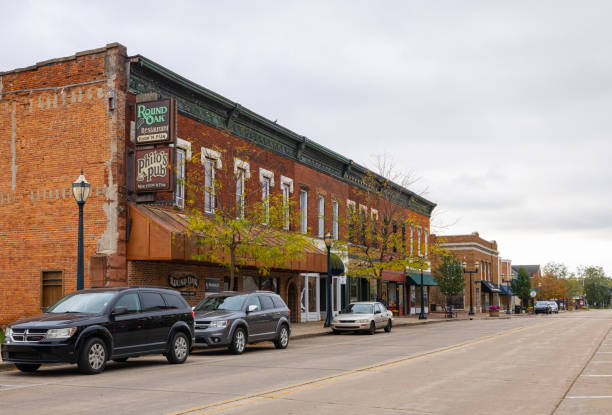

In [4]:
from transformers import pipeline
from PIL import Image
import requests

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/segmentation_input.jpg"
image = Image.open(requests.get(url, stream=True).raw)
image

In [5]:
from transformers import pipeline
semantic_segmentation = pipeline("image-segmentation", 
                                 "nvidia/segformer-b1-finetuned-cityscapes-1024-1024")

results = semantic_segmentation(image)
results

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/opt/anaconda3/envs/hf4_env/lib/python3.11/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Device set to use mps:0


[{'score': None,
  'label': 'road',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'sidewalk',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'building',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'wall',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'pole',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'traffic sign',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'vegetation',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'terrain',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'sky',
  'mask': <PIL.Image.Image image mode=L size=612x415>},
 {'score': None,
  'label': 'car',
  'mask': <PIL.Image.Image image mode=L size=612x415>}]

In [8]:
print(results[9]["label"], results[9]["score"], results[9]["mask"])
results[5]["mask"].show()

car None <PIL.Image.Image image mode=L size=612x415 at 0x33AA94650>


---

## Encoder-Decoder use-cases

### Text Translation

In [9]:
!conda install -c conda-forge sentencepiece -y

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /opt/anaconda3/envs/hf4_env

  added / updated specs:
    - sentencepiece


The following NEW packages will be INSTALLED:

  libsentencepiece   conda-forge/osx-arm64::libsentencepiece-0.2.1-h9466b84_3 
  sentencepiece      conda-forge/osx-arm64::sentencepiece-0.2.1-hd55af37_3 
  sentencepiece-pyt~ conda-forge/osx-arm64::sentencepiece-python-0.2.1-py311h40cb3f3_3 
  sentencepiece-spm  conda-forge/osx-arm64::sentencepiece-spm-0.2.1-h9466b84_3 




Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [1]:
from transformers import pipeline

# Helsinki-NLP models for 1000+ language pairs
translator = pipeline(
    "translation",
    model="Helsinki-NLP/opus-mt-en-fr"
)
result = translator("Hello, how are you?")
# [{'translation_text': 'Bonjour, comment allez-vous?'}]
print(result)
print(result[0]['translation_text'])


/opt/anaconda3/envs/hf4_env/lib/python3.11/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use mps:0


[{'translation_text': 'Bonjour, comment allez-vous ?'}]
Bonjour, comment allez-vous ?


##### Language Code Formats:
- Helsinki-NLP: ISO 639-1 (`en`, `fr`, `de`, `zh`)
- NLLB: FLORES-200 codes (`eng_Latn`, `fra_Latn`, `zho_Hans`)
- M2M-100: Similar to FLORES codes


In [2]:

# Multilingual model (NLLB - No Language Left Behind)
translator = pipeline(
    "translation",
    model="facebook/nllb-200-distilled-600M",
    src_lang="eng_Latn",  # Source language code
    tgt_lang="hin_Deva"   # Target language code
)
result = translator("Hello, how are you?")
print(result[0]['translation_text'])

Device set to use mps:0


हैलो, आप कैसे हैं?


In [3]:

# Multilingual model (NLLB - No Language Left Behind)
translator = pipeline(
    "translation",
    model="facebook/nllb-200-distilled-600M",
    src_lang="eng_Latn",  # Source language code
    tgt_lang="hin_Deva"   # Target language code
)

text = """The Linux kernel project is a free and open-source, monolithic, Unix-like operating system kernel. 
The Linux kernel was conceived and created in 1991 by Linus Torvalds for his personal computer, and it has since 
grown to support a wide variety of computer architectures, including the x86, ARM, and RISC-V instruction sets. 
The Linux kernel is released under the GNU General Public License version 2 (GPLv2), which allows anyone to view, 
modify, and distribute the source code. The kernel is developed by a large community of developers from around 
the world, with contributions from individuals, companies, and organizations. It is used as the foundation for 
many operating systems, including popular distributions such as Ubuntu, Fedora, and Debian.
"""

result = translator(text)
print(result[0]['translation_text'])

Device set to use mps:0


लिनक्स कर्नेल प्रोजेक्ट एक मुक्त और ओपन-सोर्स, मोनोलिथिक, यूनिक्स जैसी ऑपरेटिंग सिस्टम कर्नेल है। लिनक्स कर्नेल को 1991 में लिनस टोरवाल्ड्स द्वारा अपने व्यक्तिगत कंप्यूटर के लिए बनाया गया था, और तब से यह एक्स 86, एआरएम और आरआईएससी-वी निर्देश सेट सहित कई प्रकार के कंप्यूटर आर्किटेक्चर का समर्थन करने के लिए विकसित हुआ है। लिनक्स कर्नेल को जीएनयू जनरल पब्लिक लाइसेंस संस्करण 2 (जीपीएलवी 2) के तहत जारी किया जाता है, जो किसी को भी स्रोत कोड देखने, संशोधित करने और वितरित करने की अनुमति देता है। कर्नेल को दुनिया भर के डेवलपर्स के एक बड़े समुदाय द्वारा विकसित किया गया है, जिसमें व्यक्तियों, कंपनियों और संगठनों के योगदान हैं। यह उबंटू, फेडोरा और डेबियन जैसे लोकप्रिय वितरण सहित कई ऑपरेटिंग सिस्टम के लिए आधार


#### Summarization Example

In [ ]:
from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

article = """The transformer is a deep learning architecture introduced 
in the 2017 paper 'Attention Is All You Need' by Google researchers. 
Unlike previous models that processed sequences sequentially, the 
transformer uses self-attention mechanisms to process all tokens 
simultaneously, enabling much better parallelization. This breakthrough 
has led to significant advances in natural language processing, 
including models like BERT, GPT, and T5. The architecture has since 
been adapted for computer vision, speech recognition, and multimodal 
applications."""

summary = summarizer(
    article,
    max_length=50,
    min_length=20,
    do_sample=False
)
print(summary[0]['summary_text'])
# "The transformer architecture uses self-attention to process 
#  sequences in parallel. This has led to advances in NLP models 
#  like BERT, GPT, and T5."

---

### Text-to-Text Generation

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("t5-base")

# Grammar correction
input_text = "grammar: He have been working here since five years."
inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
outputs = model.generate(**inputs, max_length=128)
corrected = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(corrected)
# "He has been working here for five years."

# Question generation from context
context = """The Eiffel Tower is a wrought-iron lattice tower on the 
Champ de Mars in Paris, France. It is named after the engineer 
Gustave Eiffel, whose company designed and built the tower."""
input_text = f"generate question: {context}"
# Output: "Who designed the Eiffel Tower?"
inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
outputs = model.generate(**inputs, max_length=128)
question = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(question)


---

## Hands-on Lab: Feature Extraction with BERT (15 mins)



---
### Exercise 1: Getting Contextual Embeddings


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

# Load model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Sample sentences
sentences = [
    "I love programming in Python.",
    "The snake python is a non-venomous constrictor.",
    "Python is both a programming language and a snake species."
]

# Tokenize
inputs = tokenizer(sentences, padding=True, truncation=True, 
                   return_tensors="pt")

# Get embeddings
with torch.no_grad():
    outputs = model(**inputs)

# Extract embeddings
last_hidden_states = outputs.last_hidden_state  # [3, seq_len, 768]
cls_embeddings = last_hidden_states[:, 0, :]     # [3, 768]

# Show "Python" token embedding differs based on context!
for i, sent in enumerate(sentences):
    tokens = tokenizer.tokenize(sent)
    if 'python' in tokens:
        idx = tokens.index('python') + 1  # +1 for [CLS]
        print(f"Sentence: {sent}")
        print(f"  python embedding shape: {last_hidden_states[i, idx].shape}")
        print(f"  First 5 values: {last_hidden_states[i, idx, :5].tolist()}\n")


---

### Lab Exercise 2: Cosine Similarity of Embeddings


In [ ]:
import torch.nn.functional as F

# Get word embeddings for "python" in different contexts
def get_word_embedding(model, tokenizer, sentence, word):
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    
    tokens = tokenizer.tokenize(sentence)
    word_tokens = tokenizer.tokenize(word)
    
    # Find position (handle subword tokens)
    for i in range(len(tokens) - len(word_tokens) + 1):
        if tokens[i:i+len(word_tokens)] == word_tokens:
            # Average embeddings if word is split
            return outputs.last_hidden_state[0, i+1:i+1+len(word_tokens)].mean(0)
    return None

# Compare "python" across sentences
emb1 = get_word_embedding(model, tokenizer, 
                          "I love programming in Python.", "python")
emb2 = get_word_embedding(model, tokenizer, 
                          "The python snake is dangerous.", "python")
emb3 = get_word_embedding(model, tokenizer, 
                          "I code in Python.", "python")

# Compute similarities
sim_12 = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0))
sim_13 = F.cosine_similarity(emb1.unsqueeze(0), emb3.unsqueeze(0))
sim_23 = F.cosine_similarity(emb2.unsqueeze(0), emb3.unsqueeze(0))

print(f"Similarity: Programming Python vs Snake Python: {sim_12.item():.3f}")
print(f"Similarity: Programming Python vs Code Python: {sim_13.item():.3f}")
print(f"Similarity: Snake Python vs Code Python: {sim_23.item():.3f}")
print("\nNote: Context matters! Same word, different embeddings.")



---

### Lab Exercise 3: Text Generation with GPT-2


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load GPT-2
model_name = "gpt2"  # 124M parameters - runs on CPU!
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Add padding token (GPT-2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token

# Test different generation strategies
prompt = "In a distant future, artificial intelligence"

strategies = {
    "Greedy": {
        "do_sample": False, "max_length": 60, "num_beams": 1
    },
    "Beam Search (k=5)": {
        "do_sample": False, "max_length": 60, "num_beams": 5,
        "early_stopping": True
    },
    "Sampling (temp=0.7)": {
        "do_sample": True, "max_length": 60, "temperature": 0.7,
        "top_k": 0
    },
    "Sampling (temp=1.0, top_p=0.9)": {
        "do_sample": True, "max_length": 60, "temperature": 1.0,
        "top_p": 0.9, "top_k": 50
    }
}

for strategy, params in strategies.items():
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(**inputs, **params)
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\n{'='*50}")
    print(f"{strategy}:")
    print(f"{'='*50}")
    print(generated)
    print()



---

### Lab Exercise 4: Comparing Generation Parameters


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

prompt = "Once upon a time"

# Generate with different temperatures
temperatures = [0.1, 0.3, 0.5, 0.7, 0.9, 1.2, 1.5]

print("Effect of Temperature on Generation:\n")
for temp in temperatures:
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(
        **inputs,
        max_length=50,
        do_sample=True,
        temperature=temp,
        top_k=50,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Temperature {temp}: {generated}\n")

# Observe:
# - Low temp: Repetitive, deterministic
# - Medium temp: Coherent, natural
# - High temp: Creative but potentially incoherent



---

### Lab Exercise 5: Comparing Model Sizes


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import time

# Compare different model sizes (if available memory)
models_to_test = [
    ("gpt2", "GPT-2 (124M)"),
    ("distilgpt2", "DistilGPT-2 (82M)"),
]

for model_name, display_name in models_to_test:
    try:
        print(f"\nLoading {display_name}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(model_name)
        
        prompt = "The future of AI is"
        inputs = tokenizer(prompt, return_tensors="pt")
        
        # Time the generation
        start = time.time()
        outputs = model.generate(
            **inputs,
            max_length=50,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )
        elapsed = time.time() - start
        
        params = sum(p.numel() for p in model.parameters())
        generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        print(f"Parameters: {params:,}")
        print(f"Generation time: {elapsed:.2f}s")
        print(f"Generated: {generated[:100]}...")
        
        # Clean up memory
        del model, tokenizer
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
    except Exception as e:
        print(f"  Failed: {e}")



---

# Hands-on Lab: Translation and Summarization (15 mins)

---

## Exercise 1: Multi-Language Translation


In [ ]:
from transformers import pipeline
import torch

# Load translation pipeline
translator = pipeline(
    "translation",
    model="Helsinki-NLP/opus-mt-en-fr",
    device=0 if torch.cuda.is_available() else -1
)

# Translate sentences
english_texts = [
    "The weather is beautiful today.",
    "Machine learning is transforming industries.",
    "I would like a cup of coffee, please."
]

for text in english_texts:
    result = translator(text)
    print(f"EN: {text}")
    print(f"FR: {result[0]['translation_text']}\n")

# Try other language pairs
translators = {
    "en→fr": "Helsinki-NLP/opus-mt-en-fr",
    "en→de": "Helsinki-NLP/opus-mt-en-de",
    "en→es": "Helsinki-NLP/opus-mt-en-es",
    "en→it": "Helsinki-NLP/opus-mt-en-it",
    "en→nl": "Helsinki-NLP/opus-mt-en-nl",
}

text = "Hello, how are you?"
for lang_pair, model_name in translators.items():
    t = pipeline("translation", model=model_name)
    result = t(text)
    print(f"{lang_pair}: {result[0]['translation_text']}")



---

### Lab Exercise 2: Summarization with BART


In [ ]:
from transformers import pipeline

# Load summarization pipeline
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=-1  # Use CPU if GPU memory limited
)

# Sample long text
long_text = """
Artificial intelligence has made remarkable progress in recent years, 
particularly in the field of natural language processing. Large language 
models like GPT-3, BERT, and their successors have demonstrated impressive 
capabilities in understanding and generating human-like text. These models 
are trained on massive datasets containing billions of words from the 
internet, books, and other sources. Through a process called pre-training, 
they learn patterns in language, grammar, and even some reasoning abilities. 

However, these models also have significant limitations. They can generate 
plausible-sounding but factually incorrect information, exhibit biases 
present in their training data, and require enormous computational resources 
to train and deploy. Researchers are actively working on making these models 
more efficient, accurate, and aligned with human values. The field continues 
to evolve rapidly, with new architectures and training methods being 
developed regularly.
"""

# Generate summaries with different lengths
for length_ratio in [0.3, 0.5, 0.7]:
    # Estimate max_length based on input
    input_length = len(long_text.split())
    max_len = int(input_length * length_ratio)
    min_len = max_len // 2
    
    summary = summarizer(
        long_text,
        max_length=max_len,
        min_length=min_len,
        do_sample=False
    )
    print(f"\nSummary ({length_ratio:.0%} length, ~{max_len} words):")
    print(summary[0]['summary_text'])


---

### Lab Exercise 3: Image Classification with ViT


In [ ]:
from transformers import pipeline
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Load image classification pipeline
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Load a sample image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

# Display image
plt.imshow(image)
plt.axis('off')
plt.show()

# Classify
results = classifier(image)
for result in results[:5]:
    print(f"{result['label']}: {result['score']:.3f}")

# Try with your own images
# image = Image.open("path/to/your/image.jpg")
# results = classifier(image)



---

### Lab Exercise 4: Zero-Shot with CLIP


In [ ]:
from transformers import pipeline

# Load zero-shot image classification pipeline
classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)

# Load image
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
import requests
from PIL import Image
from io import BytesIO

response = requests.get(url)
image = Image.open(BytesIO(response.content))

# Define candidate labels (not limited to training labels!)
candidate_labels = [
    "a cat",
    "a dog",
    "a tiger",
    "a lion",
    "a rabbit",
    "a car",
    "a building",
    "food"
]

# Classify
results = classifier(image, candidate_labels=candidate_labels)
for result in results:
    print(f"{result['label']}: {result['score']:.3f}")

# Try with creative/abstract labels
creative_labels = [
    "a majestic feline",
    "a internet meme star",
    "a sleepy animal",
    "a predator",
    "someone's pet"
]

results = classifier(image, candidate_labels=creative_labels)
print("\nCreative labeling:")
for result in results:
    print(f"{result['label']}: {result['score']:.3f}")


---

### Lab Exercise 5: Speech Recognition with Whisper


In [ ]:
from transformers import pipeline
import torch

# Load ASR pipeline (use tiny model for quick testing)
transcriber = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-tiny",
    device=0 if torch.cuda.is_available() else -1
)

# If you have an audio file:
# audio_file = "path/to/audio.mp3"
# result = transcriber(audio_file)
# print(f"Transcription: {result['text']}")

# For testing without audio file - create a note about setup
print("To test speech recognition:")
print("1. Install required packages:")
print("   pip install librosa soundfile")
print()
print("2. Use with audio file:")
print('   result = transcriber("audio.mp3")')
print('   print(result["text"])')
print()
print("Whisper models available:")
print("  whisper-tiny:   39M parameters (fastest)")
print("  whisper-base:   74M parameters")
print("  whisper-small:  244M parameters")
print("  whisper-medium: 769M parameters")
print("  whisper-large:  1.5B parameters (best quality)")

# Demo with a sample from HuggingFace dataset
from datasets import load_dataset

print("\nLoading sample from LibriSpeech...")
try:
    # Load a sample
    dataset = load_dataset("librispeech_asr", "clean", split="test", streaming=True)
    sample = next(iter(dataset))
    
    # Transcribe
    result = transcriber(sample["audio"]["array"])
    print(f"Transcription: {result['text']}")
    print(f"Reference: {sample['text']}")
except Exception as e:
    print(f"Couldn't load sample: {e}")
    print("This is expected if you don't have audio dependencies installed.")


---

### Lab Exercise 6: Multi-Model Pipeline Chain


In [ ]:
from transformers import pipeline
from PIL import Image
import requests
from io import BytesIO

# Create a chain: Image → Caption → Translation
print("Creating multi-model pipeline chain...")

# 1. Image captioning
captioner = pipeline(
    "image-to-text",
    model="nlpconnect/vit-gpt2-image-captioning"
)

# 2. Translation (English → French)
translator = pipeline(
    "translation_en_to_fr",
    model="Helsinki-NLP/opus-mt-en-fr"
)

# 3. Sentiment analysis on caption
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# Process an image through the chain
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

print("\n1. Generating caption...")
caption = captioner(image)[0]['generated_text']
print(f"   Caption: {caption}")

print("\n2. Translating to French...")
translated = translator(caption)[0]['translation_text']
print(f"   French: {translated}")

print("\n3. Analyzing sentiment of caption...")
sentiment = sentiment_analyzer(caption)[0]
print(f"   Sentiment: {sentiment['label']} (confidence: {sentiment['score']:.3f})")

print("\n" + "="*50)
print("Pipeline Chain Complete!")
print(f"  Input: Image of a cat")
print(f"  → Caption: {caption}")
print(f"  → Translation: {translated}")
print(f"  → Sentiment: {sentiment['label']}")

